# DATA-445 — Homework Assignment 1

**Instructions**

- This homework assignment is worth 94 points.
- Please submit a `.ipynb` file to Blackboard.
- Please strive for clarity and organization.
- **AI usage**:
  - AI use is strictly **prohibited** for conceptual exercises.
  - For applied (Python) exercises, you may use AI exclusively for **debugging**. Do not use AI to generate answers.
- **Due Date: September 11, 2026, by 11:59 PM.**

## Exercise 1

(4 points) What type of algorithm would you use to segment a company customers database into multiple groups?

I think you would use K-Clustering, which is unsupervised learning. This allows you to segment your customers into multiple groups based on similarities in specific characteristics. 

## Exercise 2

(4 points) Would you frame the problem of spam detection as a supervised learning problem or an unsupervised learning problem? Explain.

I would frame spam detection as supervised learning. The model would be using training data already labeled as spam or not spam to learn the trend of whether or not a new email is spam. 

## Exercise 3

(4 points) What is a test set, and why would you want to use it?

A test set would be a part of the data you save for when the training is done to test the model on new untrained data.

## Exercise 4

(4 points) You are training a classification model with 100 variables/features that achieves 95% accuracy in the training dataset. However, when you run it in the test dataset, you only get 60% accuracy. Which of the following options are valid approached to solve this problem?

- (a) Reduce the number of input variables/features
- (b) Add extra variables/features
- (c) Implement cross-validation during the training process
- (d) Select another algorithm
- (e) (a) and (c)
- (f) (a) and (d)
- (g) (b) and (c)
- (h) (b) and (d)
- (i) None of the above

I think (f). (a) and (d) because it looks like the model might have been overfit so reducing the number of input variables might help even out the difference between training and test data or selecting another algo to work with code also close the gap.

## Exercise 5

Consider the `Real_Estate.csv` data file posted on Blackboard (under the In-Class 3f assignment link). This file contains information related to 414 houses. The goal is to predict the house price of unit area. In **Python**, answer the following:

### (a) (3 points)

Using the pandas library, read the csv data file and create a data-frame called `house_price`.

In [25]:
import pandas as pd
import seaborn as sns
# import numpy as np
import matplotlib.pyplot as plt
# from sklearn.linear_model import Lasso (or Ridge or ElasticNet)
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

house_price = pd.read_csv("Real_Estate.csv")
house_price.head()

,No,transaction_date,house_age,distance_to_the_nearest_MRT_station,number_of_convenience_stores,latitude,longitude,house_price_of_unit_area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


### (b) (3 points)

Drop the `No` and `transaction_date` columns.

In [10]:
house_price = house_price.drop(columns = ['No', 'transaction_date'])
house_price.head()

,house_age,distance_to_the_nearest_MRT_station,number_of_convenience_stores,latitude,longitude,house_price_of_unit_area
0,32.0,84.87882,10,24.98298,121.54024,37.9
1,19.5,306.59470,9,24.98034,121.53951,42.2
2,13.3,561.98450,5,24.98746,121.54391,47.3
3,13.3,561.98450,5,24.98746,121.54391,54.8
4,5.0,390.56840,5,24.97937,121.54245,43.1


### (c) (4 points)

Split the data-frame into two data-frames: train (80%) and test (20%).

In [11]:
x = house_price[['house_age', 'distance_to_the_nearest_MRT_station', 'number_of_convenience_stores', 'latitude', 'longitude']]
Y = house_price['house_price_of_unit_area']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


### (d) (8 points)

Using the `house_price` data-frame, compute the correlation between each input variable and `house_price_of_unit_area`, and display the results as a heatmap. Which two variables are most correlated (in absolute value) with the target variable?

house_age                             -0.210567
distance_to_the_nearest_MRT_station   -0.673613
number_of_convenience_stores           0.571005
latitude                               0.546307
longitude                              0.523287
house_price_of_unit_area               1.000000
Name: house_price_of_unit_area, dtype: float64


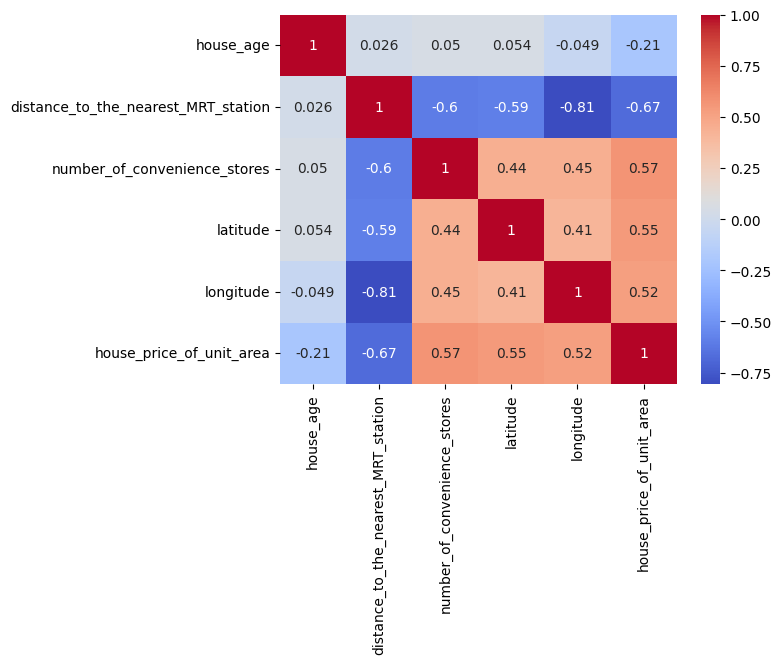

In [16]:
corr = house_price[['house_age', 'distance_to_the_nearest_MRT_station', 'number_of_convenience_stores', 'latitude', 'longitude', 'house_price_of_unit_area']].corr()
print(corr['house_price_of_unit_area'])
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


### (e) (10 points)

Using the train data-frame, build a linear regression model in which: `house_age`, `distance_to_the_nearest_MRT_station`, `number_of_convenience_stores`, `latitude`, and `longitude` are the input variables, and `house_price_of_unit_area` is the target variable. After the model is built, predict the house price of unit area of the houses in the test data-frame. Report the MSE.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(house_price[['house_age', 'distance_to_the_nearest_MRT_station', 'number_of_convenience_stores', 'latitude', 'longitude']],  house_price['house_price_of_unit_area'],  test_size=0.2,  random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", round(mse, 2))

Mean Squared Error: 54.58


### (f) (10 points)

Using the train data-frame, build a linear regression model in which: `house_age`, `number_of_convenience_stores`, `latitude`, and `longitude` are the input variables, and `house_price_of_unit_area` is the target variable. After the model is built, predict the house price of unit area of the houses in the test data-frame. Report the MSE.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(house_price[['house_age', 'number_of_convenience_stores', 'latitude', 'longitude']],  house_price['house_price_of_unit_area'],  test_size=0.2,  random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", round(mse, 2))

Mean Squared Error: 57.76


### (g) (5 points)

Using the results from parts (e) and (f), what model would you use? Explain.

I would use the MSE from part e because it is lower than part f, a 54.58 to 57.76, around a 3 point difference. The lower MSE shows that the model from part e makes more accurate predictions for the house price of unit area.

### (h) (15 points)

Repeat steps (c) to (e) 100 times, and visualize the MSE of each of the models at each iteration. Which of the two model has better performance on the test datasets? Explain.

In [36]:
mse_model_e = []
mse_model_f = []

for i in range(100):
    X_train, X_test, y_train, y_test = train_test_split(house_price[['house_age', 'distance_to_the_nearest_MRT_station', 'number_of_convenience_stores', 'latitude', 'longitude']],  house_price['house_price_of_unit_area'],  test_size=0.2,  random_state=42)

# model e
    X_train_e = house_price[['house_age', 'distance_to_the_nearest_MRT_station', 'number_of_convenience_stores', 'latitude', 'longitude']]

    y_train_e = house_price['house_price_of_unit_area']

    X_test_e = house_price[['house_age', 'distance_to_the_nearest_MRT_station', 'number_of_convenience_stores', 'latitude', 'longitude']]

y_test_e = house_price['house_price_of_unit_area']

model_e = LinearRegression()
model_e.fit(X_train_e, y_train_e)

y_pred_e = model_e.predict(X_test_e)

mse_e = mean_squared_error(y_test_e, y_pred_e)
mse_model_e.append(mse_e)


# model f
X_train_f = house_price[['house_age', 'number_of_convenience_stores', 'latitude', 'longitude']]

y_train_f = house_price['house_price_of_unit_area']

X_test_f = house_price[['house_age', 'number_of_convenience_stores', 'latitude', 'longitude']]

y_test_f = house_price['house_price_of_unit_area']

model_f = LinearRegression()
model_f.fit(X_train_f, y_train_f)

y_pred_f = model_f.predict(X_test_f)

mse_f = mean_squared_error(y_test_f, y_pred_f)
mse_model_f.append(mse_f)

print("Average MSE Model E:", round(sum(mse_model_e) / 100, 3))
print("Average MSE Model F:", round(sum(mse_model_f) / 100, 3))

Average MSE Model E: 0.792
Average MSE Model F: 0.859


Model e still has better preformance even over 100 tests. The result shows that the model does better when distance to the nearest MRT station is included.

### (i) (8 points) 
Using scikit-learn's `cross_val_score`, perform 10-fold cross-validation on the full model from Exercise 5, part (d) (using the entire `house_price` data-frame). Report the average MSE across the 10 folds.

In [41]:
from sklearn.model_selection import cross_val_score

X = house_price[['house_age', 'distance_to_the_nearest_MRT_station', 'number_of_convenience_stores', 'latitude', 'longitude']]
Y = house_price['house_price_of_unit_area']
mse_scores = cross_val_score(lin_reg, X, Y, cv=10, scoring='neg_mean_squared_error')
mse_scores = -mse_scores
average_mse = mse_scores.mean()

print("MSE for each fold:", mse_scores.round(3))
print("Average MSE:", round(average_mse, 3))



MSE for each fold: [ 56.265  53.133  82.931 104.312  37.444  67.155 203.659  80.497  51.262
  73.454]
Average MSE: 81.011


## Exercise 6

(6 points) Explain the bias-variance tradeoff, and describe how it relates to a model's ability to generalize to new/unseen data.

High bias is underfitting and low bias is overfitting. The tradeoff is trying to get a model that's not too complex and not too simple. The goal of the model is to find important patterns without memorizing the training data. If you can balance this then the model can generalize better. It allows the model to make more accurate predictions on new data.

## Exercise 7

(6 points) The "curse of dimensionality" refers to the difficulties that arise when working with data that has a very large number of features. Explain why having too many features can hurt the performance of a machine learning model, and describe one strategy to mitigate this problem.

Having too many variables or "features" can hurt the model by adding irrelevant data or add extra data. This makes it harder for the model to find patterns in the data. This will increase the likleyhood of overfitting the model. One way to mitigate the problem is feature selection, this is the act of removing irrelevant features and keeping the ones most relevant for useful predictions. 